In [2]:
# 🤖 Classificador de Espécies — Dataset Íris

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Carregar dados
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

print(f"✅ Dados carregados: {X.shape[0]} amostras, {X.shape[1]} features")
print(f"🎯 Classes: {iris.target_names}")

✅ Dados carregados: 150 amostras, 4 features
🎯 Classes: ['setosa' 'versicolor' 'virginica']


In [3]:
# Separar 80% treino, 20% teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"📚 Treino: {X_train.shape[0]} amostras")
print(f"🧪 Teste: {X_test.shape[0]} amostras")

📚 Treino: 120 amostras
🧪 Teste: 30 amostras


In [4]:
# Treinar K-Nearest Neighbors
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("📊 KNN — Relatório de Classificação:")
print(classification_report(y_test, y_pred_knn, target_names=iris.target_names))

📊 KNN — Relatório de Classificação:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [5]:
# Treinar Árvore de Decisão
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("🌳 Árvore de Decisão — Relatório de Classificação:")
print(classification_report(y_test, y_pred_dt, target_names=iris.target_names))

🌳 Árvore de Decisão — Relatório de Classificação:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



🏆 Comparação de Modelos:
              Modelo  Acurácia
0          KNN (k=3)  1.000000
1  Árvore de Decisão  0.933333


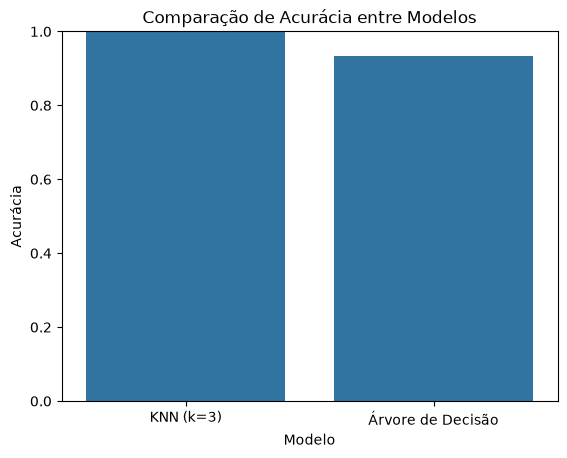

In [6]:
# Comparação
resultados = pd.DataFrame({
    'Modelo': ['KNN (k=3)', 'Árvore de Decisão'],
    'Acurácia': [
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt)
    ]
})

print("🏆 Comparação de Modelos:")
print(resultados)

# Gráfico
sns.barplot(data=resultados, x='Modelo', y='Acurácia')
plt.ylim(0, 1)
plt.title('Comparação de Acurácia entre Modelos')
plt.show()

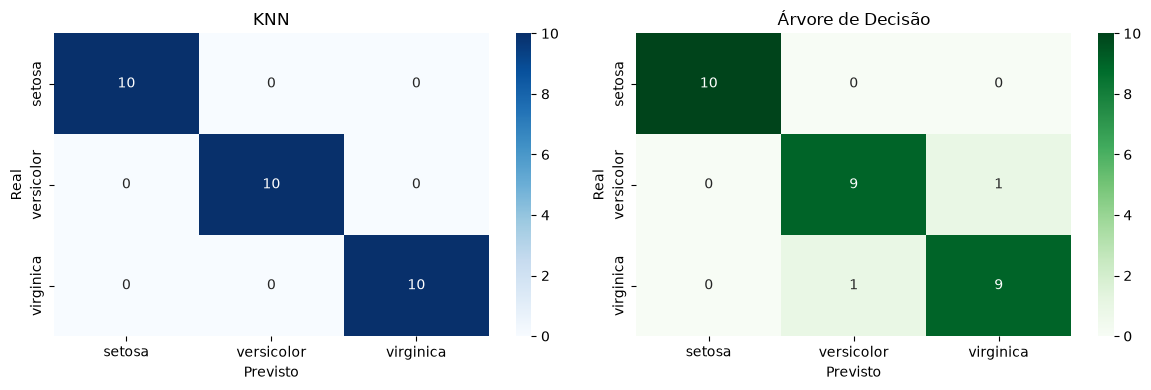

In [7]:
# Matriz de confusão do melhor modelo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(confusion_matrix(y_test, y_pred_knn), 
            annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=iris.target_names, yticklabels=iris.target_names)
axes[0].set_title('KNN')
axes[0].set_xlabel('Previsto')
axes[0].set_ylabel('Real')

sns.heatmap(confusion_matrix(y_test, y_pred_dt), 
            annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=iris.target_names, yticklabels=iris.target_names)
axes[1].set_title('Árvore de Decisão')
axes[1].set_xlabel('Previsto')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()